# HW08-09:
# Тема: PyTorch — многослойный перцептрон и методы оптимизации.
# Часть S08: MLP и регуляризация (Dropout, BatchNorm, EarlyStopping).
# Часть S09: диагностика learning rate, сравнение Adam и SGD+momentum, weight decay.


### 1. ПОДКЛЮЧЕНИЕ БИБЛИОТЕК, ИНИЦИАЛИЗАЦИЯ SEED И ВЫБОР УСТРОЙСТВА

In [1]:
# Подключаем все нужные модули
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from sklearn.metrics import accuracy_score

os.makedirs('artifacts/figures', exist_ok=True)

# Задаём seed для получения воспроизводимых результатов
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Выбираем вычислительное устройство: GPU при наличии, иначе CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Активное устройство: {device}")


Используемое устройство: cpu


### 2. ЗАГРУЗКА ДАННЫХ И ФОРМИРОВАНИЕ ЗАГРУЗЧИКОВ

In [2]:
DATASET_NAME = 'CIFAR10'

# Составляем цепочку преобразований: перевод в тензор и нормализация к [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Скачиваем тренировочную и тестовую части датасета
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Датасет: {DATASET_NAME}")
print(f"Обучающих примеров: {len(train_dataset)}")
print(f"Тестовых примеров: {len(test_dataset)}")

# Разбиваем тренировочную выборку на train и val в соотношении 80/20
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Создаём DataLoader для каждого раздела
BATCH_SIZE = 64

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Проверяем форму первого батча
for x, y in train_loader:
    print(f"Форма батча: x={x.shape}, y={y.shape}")
    print(f"Диапазон значений: [{x.min():.3f}, {x.max():.3f}]")
    break


Датасет: CIFAR10
Размер тренировочной выборки: 50000
Размер тестовой выборки: 10000
Shape батча: x=torch.Size([64, 3, 32, 32]), y=torch.Size([64])
Диапазон значений x: [-1.000, 1.000]


### 3. АРХИТЕКТУРА MLP И ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ОБУЧЕНИЯ

In [3]:
# Класс многослойного перцептрона с настраиваемой регуляризацией
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout=0.0, use_batchnorm=False):
        super(MLP, self).__init__()

        layer_list = []
        in_features = input_size

        for out_features in hidden_sizes:
            layer_list.append(nn.Linear(in_features, out_features))
            if use_batchnorm:
                layer_list.append(nn.BatchNorm1d(out_features))
            layer_list.append(nn.ReLU())
            if dropout > 0:
                layer_list.append(nn.Dropout(dropout))
            in_features = out_features

        layer_list.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layer_list)

    def forward(self, x):
        # Разворачиваем изображение в вектор перед подачей в сеть
        x = x.view(x.size(0), -1)
        return self.network(x)


# Один шаг обучения: прямой и обратный проходы по всем батчам
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    predictions, targets = [], []

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        _, predicted = torch.max(logits, 1)
        predictions.extend(predicted.cpu().numpy())
        targets.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(targets, predictions)
    return epoch_loss, epoch_acc


# Оценка модели без обновления весов
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    predictions, targets = [], []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * x_batch.size(0)
            _, predicted = torch.max(logits, 1)
            predictions.extend(predicted.cpu().numpy())
            targets.extend(y_batch.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    avg_acc = accuracy_score(targets, predictions)
    return avg_loss, avg_acc


### 4. ГИПЕРПАРАМЕТРЫ ЭКСПЕРИМЕНТОВ

In [4]:
# Вычисляем размер входного вектора (пиксели * каналы)
INPUT_SIZE = np.prod(train_dataset[0][0].shape)
NUM_CLASSES = len(train_dataset.classes) if hasattr(train_dataset, 'classes') else 10
HIDDEN_SIZES = [256, 128]  # Два скрытых слоя

# Базовые параметры обучения
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3

# Функция потерь для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

print(f"Размер входа: {INPUT_SIZE}")
print(f"Число классов: {NUM_CLASSES}")
print(f"Скрытые слои: {HIDDEN_SIZES}")


Входной размер: 3072
Количество классов: 10
Архитектура: [256, 128]


### 5. КЛАСС ДЛЯ УПРАВЛЕНИЯ ЭКСПЕРИМЕНТАМИ

In [5]:
class Experiment:
    def __init__(self, experiment_id, dropout=0.0, use_batchnorm=False,
                 optimizer='adam', lr=0.001, momentum=0.9, weight_decay=0.0,
                 use_early_stopping=False, patience=3):
        self.experiment_id = experiment_id
        self.dropout = dropout
        self.use_batchnorm = use_batchnorm
        self.optimizer_name = optimizer
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.use_early_stopping = use_early_stopping
        self.patience = patience

        # Списки для хранения метрик по эпохам
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

    def run(self, model, train_loader, val_loader, criterion, device, num_epochs):
        # Создаём оптимизатор в зависимости от настроек
        if self.optimizer_name == 'adam':
            optimizer = optim.Adam(model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        elif self.optimizer_name == 'sgd':
            optimizer = optim.SGD(model.parameters(), lr=self.lr,
                                  momentum=self.momentum, weight_decay=self.weight_decay)

        best_val_acc = 0
        best_val_loss = float('inf')
        no_improve_count = 0
        saved_state = None

        for epoch in range(num_epochs):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)

            self.train_losses.append(tr_loss)
            self.val_losses.append(vl_loss)
            self.train_accs.append(tr_acc)
            self.val_accs.append(vl_acc)

            # Сохраняем веса, если val_accuracy улучшилась
            if vl_acc > best_val_acc:
                best_val_acc = vl_acc
                best_val_loss = vl_loss
                saved_state = model.state_dict().copy()
                no_improve_count = 0
            else:
                no_improve_count += 1

            # Ранняя остановка при отсутствии прогресса
            if self.use_early_stopping and no_improve_count >= self.patience:
                print(f"Ранняя остановка на эпохе {epoch + 1}")
                break

            if (epoch + 1) % 5 == 0:
                print(f"Эпоха {epoch + 1}: Train Loss={tr_loss:.4f}, Val Acc={vl_acc:.4f}")

        # Восстанавливаем лучшие веса
        if saved_state is not None:
            model.load_state_dict(saved_state)

        return best_val_acc, best_val_loss, epoch + 1

    def plot_curves(self, save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(self.train_losses, label='Train Loss')
        axes[0].plot(self.val_losses, label='Val Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title(f'{self.experiment_id} — Loss')
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(self.train_accs, label='Train Acc')
        axes[1].plot(self.val_accs, label='Val Acc')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title(f'{self.experiment_id} — Accuracy')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()


### 6. ЧАСТЬ A (S08) — РЕГУЛЯРИЗАЦИЯ (E1–E4)

**E1:** Базовая модель — 2 скрытых слоя, без Dropout и BatchNorm


ЭКСПЕРИМЕНТ E1: Base (без регуляризации)
Эпоха 5: Train Loss=1.1802, Val Acc=0.5273
Эпоха 10: Train Loss=0.8525, Val Acc=0.5278
Эпоха 15: Train Loss=0.6040, Val Acc=0.5231
Эпоха 20: Train Loss=0.4321, Val Acc=0.5189


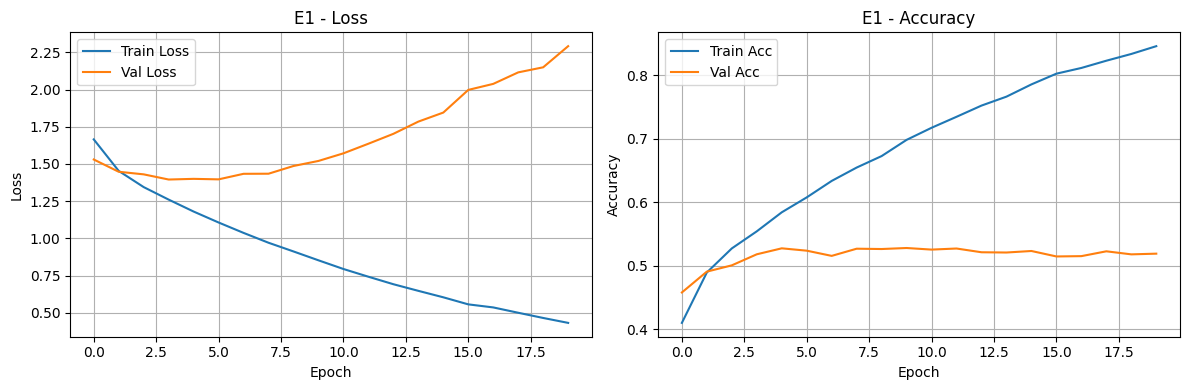

In [6]:
results = []

print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E1: базовая конфигурация (без регуляризации)")
print("="*60)

model_e1 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, dropout=0.0, use_batchnorm=False).to(device)
exp_e1 = Experiment('E1', dropout=0.0, use_batchnorm=False, optimizer='adam', lr=LEARNING_RATE)
best_val_acc_e1, best_val_loss_e1, epochs_e1 = exp_e1.run(
    model_e1, train_loader, val_loader, criterion, device, NUM_EPOCHS
)
exp_e1.plot_curves(save_path='artifacts/figures/curves_E1.png')

results.append({
    'experiment_id': 'E1',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout=0.0, batchnorm=False',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e1,
    'best_val_accuracy': best_val_acc_e1,
    'best_val_loss': best_val_loss_e1
})


**E2:** Добавляем Dropout(p=0.3) к базовой модели E1


ЭКСПЕРИМЕНТ E2: Dropout (p=0.3)
Эпоха 5: Train Loss=1.4918, Val Acc=0.4900
Эпоха 10: Train Loss=1.3664, Val Acc=0.5116
Эпоха 15: Train Loss=1.2800, Val Acc=0.5247
Эпоха 20: Train Loss=1.2150, Val Acc=0.5222


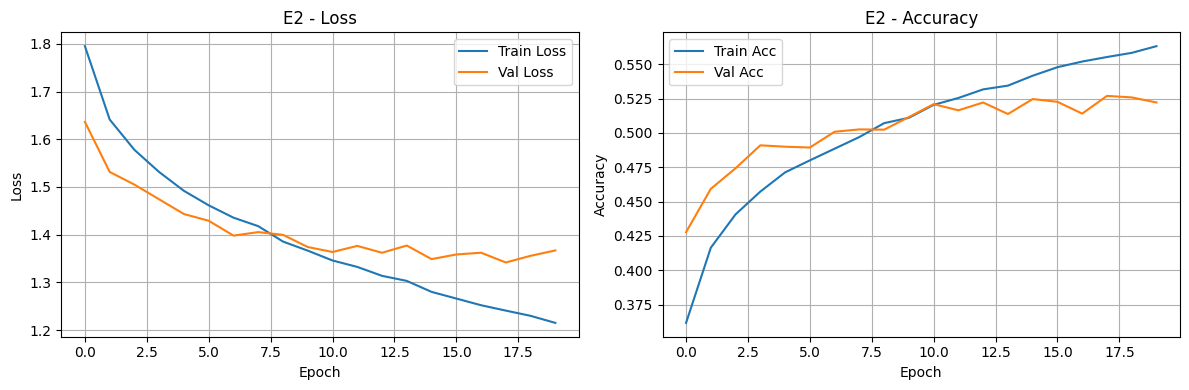

In [7]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E2: Dropout p=0.3")
print("="*60)

model_e2 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, dropout=0.3, use_batchnorm=False).to(device)
exp_e2 = Experiment('E2', dropout=0.3, use_batchnorm=False, optimizer='adam', lr=LEARNING_RATE)
best_val_acc_e2, best_val_loss_e2, epochs_e2 = exp_e2.run(
    model_e2, train_loader, val_loader, criterion, device, NUM_EPOCHS
)
exp_e2.plot_curves(save_path='artifacts/figures/curves_E2.png')

results.append({
    'experiment_id': 'E2',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout=0.3, batchnorm=False',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e2,
    'best_val_accuracy': best_val_acc_e2,
    'best_val_loss': best_val_loss_e2
})


**E3:** Добавляем BatchNorm к базовой модели E1


ЭКСПЕРИМЕНТ E3: BatchNorm
Эпоха 5: Train Loss=1.1797, Val Acc=0.5355
Эпоха 10: Train Loss=0.9171, Val Acc=0.5456
Эпоха 15: Train Loss=0.7051, Val Acc=0.5469
Эпоха 20: Train Loss=0.5397, Val Acc=0.5439


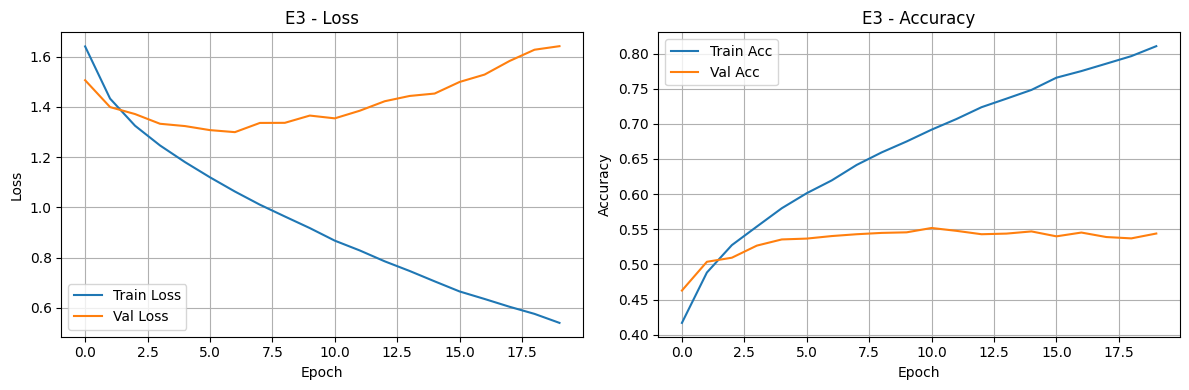

In [8]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E3: BatchNorm")
print("="*60)

model_e3 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, dropout=0.0, use_batchnorm=True).to(device)
exp_e3 = Experiment('E3', dropout=0.0, use_batchnorm=True, optimizer='adam', lr=LEARNING_RATE)
best_val_acc_e3, best_val_loss_e3, epochs_e3 = exp_e3.run(
    model_e3, train_loader, val_loader, criterion, device, NUM_EPOCHS
)
exp_e3.plot_curves(save_path='artifacts/figures/curves_E3.png')

results.append({
    'experiment_id': 'E3',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout=0.0, batchnorm=True',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e3,
    'best_val_accuracy': best_val_acc_e3,
    'best_val_loss': best_val_loss_e3
})


**E4:** EarlyStopping поверх лучшей конфигурации из E2/E3


ЭКСПЕРИМЕНТ E4: EarlyStopping
Лучшая база: E3 (Val Acc=0.5518)
Эпоха 5: Train Loss=1.1820, Val Acc=0.5427
Эпоха 10: Train Loss=0.9132, Val Acc=0.5392
Ранняя остановка на эпохе 12


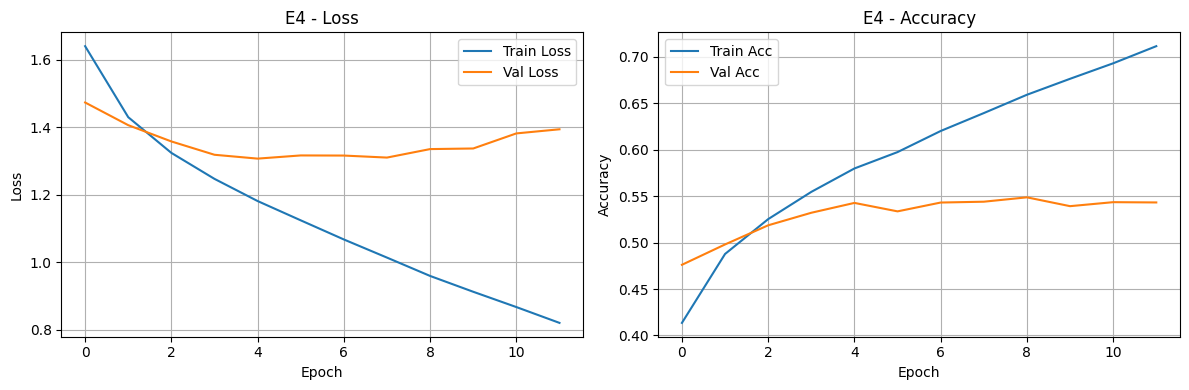


Лучшая модель сохранена в artifacts/best_model.pt
Конфиг сохранен в artifacts/best_config.json


In [9]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E4: EarlyStopping")
print("="*60)

# Берём настройки лучшего из E2/E3 как основу
if best_val_acc_e2 >= best_val_acc_e3:
    best_dropout = 0.3
    best_batchnorm = False
    base_exp = 'E2'
else:
    best_dropout = 0.0
    best_batchnorm = True
    base_exp = 'E3'

print(f"Выбранная база: {base_exp} (Val Acc={max(best_val_acc_e2, best_val_acc_e3):.4f})")

model_e4 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout=best_dropout, use_batchnorm=best_batchnorm).to(device)
exp_e4 = Experiment('E4', dropout=best_dropout, use_batchnorm=best_batchnorm,
                    optimizer='adam', lr=LEARNING_RATE,
                    use_early_stopping=True, patience=EARLY_STOPPING_PATIENCE)
best_val_acc_e4, best_val_loss_e4, epochs_e4 = exp_e4.run(
    model_e4, train_loader, val_loader, criterion, device, NUM_EPOCHS
)
exp_e4.plot_curves(save_path='artifacts/figures/curves_best.png')

results.append({
    'experiment_id': 'E4',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': (
        f'hidden={HIDDEN_SIZES}, dropout={best_dropout}, '
        f'batchnorm={best_batchnorm}, early_stopping=True'
    ),
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_e4,
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': best_val_loss_e4
})

# Сохраняем веса лучшей модели
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')

# Формируем и сохраняем конфигурацию лучшей модели
best_config = {
    'experiment_id': 'E4',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'input_size': INPUT_SIZE,
    'hidden_sizes': HIDDEN_SIZES,
    'num_classes': NUM_CLASSES,
    'dropout': best_dropout,
    'use_batchnorm': best_batchnorm,
    'optimizer': 'Adam',
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE
}


def convert_numpy_types(obj):
    """Приводит типы NumPy к стандартным Python-типам для корректной сериализации"""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_numpy_types(item) for item in obj]
    return obj


best_config = convert_numpy_types(best_config)

with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=4, ensure_ascii=False)

print("Лучшая модель сохранена: artifacts/best_model.pt")
print("Конфигурация сохранена: artifacts/best_config.json")


### 7. ЧАСТЬ B (S09) — LEARNING RATE, ОПТИМИЗАТОРЫ, WEIGHT DECAY (O1–O3)

**O1:** Завышенный learning rate — Adam, lr=0.1


ЭКСПЕРИМЕНТ O1: LR слишком большой (lr=0.1)
Эпоха 5: Train Loss=1.5149, Val Acc=0.4502
Эпоха 10: Train Loss=1.3831, Val Acc=0.4861


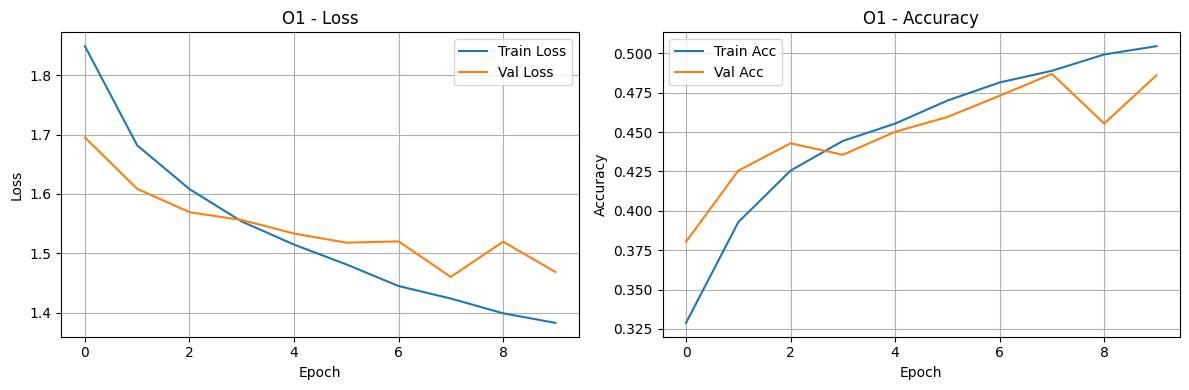

In [10]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O1: завышенный LR (lr=0.1)")
print("="*60)

model_o1 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout=best_dropout, use_batchnorm=best_batchnorm).to(device)
exp_o1 = Experiment('O1', dropout=best_dropout, use_batchnorm=best_batchnorm,
                    optimizer='adam', lr=0.1)
best_val_acc_o1, best_val_loss_o1, epochs_o1 = exp_o1.run(
    model_o1, train_loader, val_loader, criterion, device, num_epochs=10
)
exp_o1.plot_curves(save_path='artifacts/figures/curves_lr_high.png')

results.append({
    'experiment_id': 'O1',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={best_dropout}, batchnorm={best_batchnorm}',
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_o1,
    'best_val_accuracy': best_val_acc_o1,
    'best_val_loss': best_val_loss_o1
})


**O2:** Заниженный learning rate — Adam, lr=0.00001


ЭКСПЕРИМЕНТ O2: LR слишком маленький (lr=0.00001)
Эпоха 5: Train Loss=1.5939, Val Acc=0.4666
Эпоха 10: Train Loss=1.4237, Val Acc=0.4991


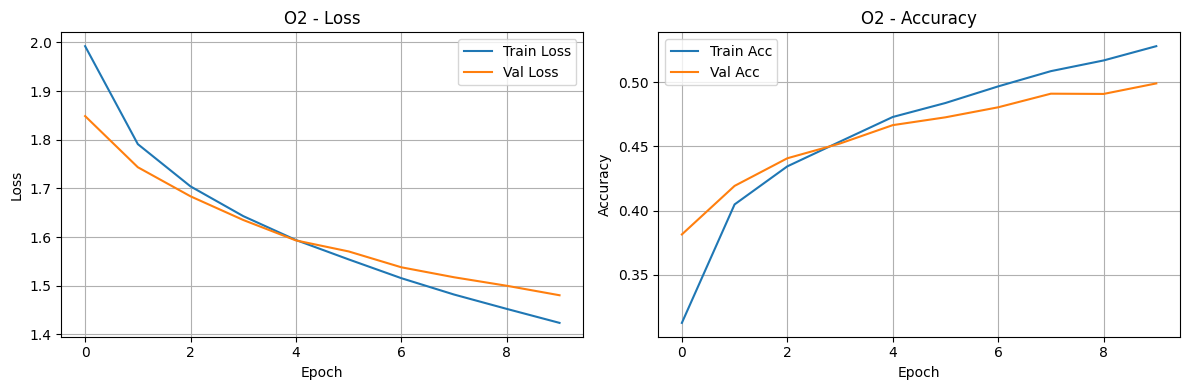

In [11]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O2: заниженный LR (lr=0.00001)")
print("="*60)

model_o2 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout=best_dropout, use_batchnorm=best_batchnorm).to(device)
exp_o2 = Experiment('O2', dropout=best_dropout, use_batchnorm=best_batchnorm,
                    optimizer='adam', lr=0.00001)
best_val_acc_o2, best_val_loss_o2, epochs_o2 = exp_o2.run(
    model_o2, train_loader, val_loader, criterion, device, num_epochs=10
)
exp_o2.plot_curves(save_path='artifacts/figures/curves_lr_low.png')

results.append({
    'experiment_id': 'O2',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={best_dropout}, batchnorm={best_batchnorm}',
    'optimizer': 'Adam',
    'lr': 0.00001,
    'momentum': 0,
    'weight_decay': 0,
    'epochs_trained': epochs_o2,
    'best_val_accuracy': best_val_acc_o2,
    'best_val_loss': best_val_loss_o2
})


**O3:** SGD с momentum и weight_decay (lr=0.01, momentum=0.9, weight_decay=0.0001)


ЭКСПЕРИМЕНТ O3: SGD+momentum + weight_decay
Эпоха 5: Train Loss=1.1893, Val Acc=0.5299
Эпоха 10: Train Loss=0.9437, Val Acc=0.5342
Эпоха 15: Train Loss=0.7636, Val Acc=0.5287


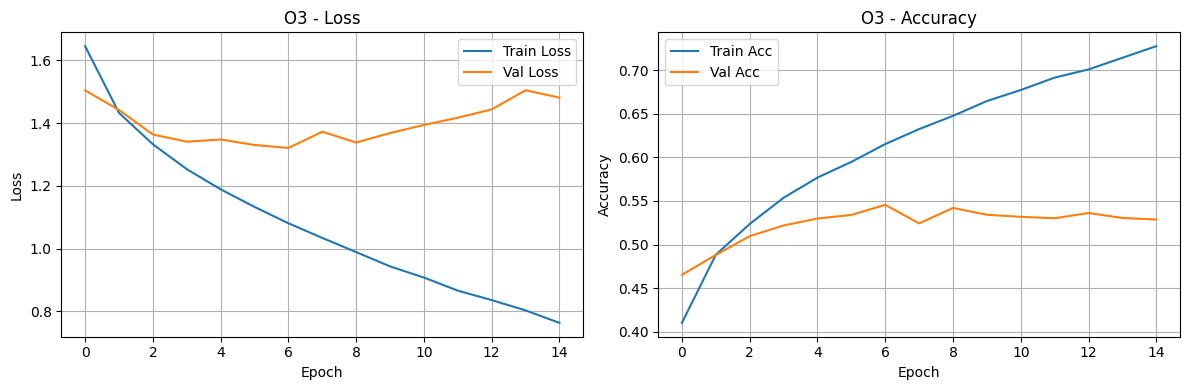

In [12]:
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O3: SGD + momentum + weight_decay")
print("="*60)

model_o3 = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
               dropout=best_dropout, use_batchnorm=best_batchnorm).to(device)
exp_o3 = Experiment('O3', dropout=best_dropout, use_batchnorm=best_batchnorm,
                    optimizer='sgd', lr=0.01, momentum=0.9, weight_decay=0.0001)
best_val_acc_o3, best_val_loss_o3, epochs_o3 = exp_o3.run(
    model_o3, train_loader, val_loader, criterion, device, num_epochs=15
)
exp_o3.plot_curves(save_path='artifacts/figures/curves_sgd.png')

results.append({
    'experiment_id': 'O3',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': f'hidden={HIDDEN_SIZES}, dropout={best_dropout}, batchnorm={best_batchnorm}',
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 0.0001,
    'epochs_trained': epochs_o3,
    'best_val_accuracy': best_val_acc_o3,
    'best_val_loss': best_val_loss_o3
})


Сводный график сравнения крайних значений LR (O1 и O2)

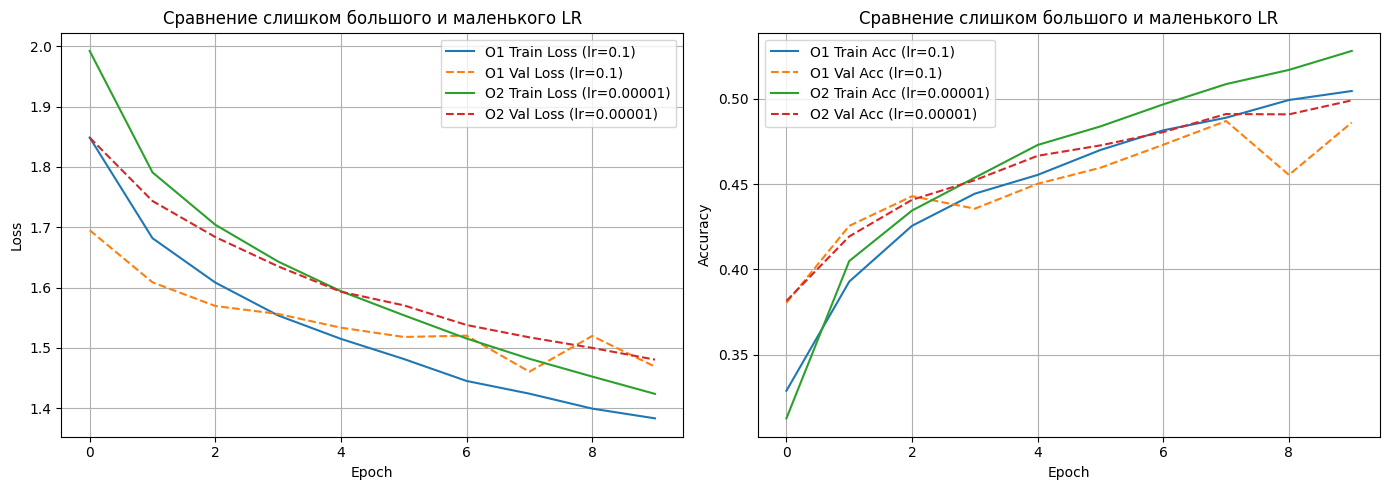

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(exp_o1.train_losses, label='O1 Train (lr=0.1)',      linestyle='-')
axes[0].plot(exp_o1.val_losses,   label='O1 Val   (lr=0.1)',      linestyle='--')
axes[0].plot(exp_o2.train_losses, label='O2 Train (lr=0.00001)',  linestyle='-')
axes[0].plot(exp_o2.val_losses,   label='O2 Val   (lr=0.00001)',  linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Завышенный vs заниженный LR — Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(exp_o1.train_accs, label='O1 Train (lr=0.1)',      linestyle='-')
axes[1].plot(exp_o1.val_accs,   label='O1 Val   (lr=0.1)',      linestyle='--')
axes[1].plot(exp_o2.train_accs, label='O2 Train (lr=0.00001)',  linestyle='-')
axes[1].plot(exp_o2.val_accs,   label='O2 Val   (lr=0.00001)',  linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Завышенный vs заниженный LR — Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150)
plt.show()


### 8. СОХРАНЕНИЕ ИТОГОВОЙ ТАБЛИЦЫ

Записываем сводку всех прогонов в CSV

In [14]:
df_results = pd.DataFrame(results)
df_results.to_csv('artifacts/runs.csv', index=False, encoding='utf-8-sig')
print("Таблица результатов сохранена: artifacts/runs.csv")


Результаты сохранены в artifacts/runs.csv


Финальное тестирование лучшей модели на отложенной выборке

In [15]:
print("\n" + "="*60)
print("ИТОГОВАЯ ОЦЕНКА НА TEST SET")
print("="*60)

# Загружаем сохранённые веса и прогоняем модель по тестовой выборке
model_best = MLP(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES,
                 dropout=best_dropout, use_batchnorm=best_batchnorm).to(device)
model_best.load_state_dict(torch.load('artifacts/best_model.pt', map_location=device))

test_loss, test_acc = evaluate(model_best, test_loader, criterion, device)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")



ФИНАЛЬНАЯ ОЦЕНКА НА TEST
Test Accuracy: 0.5387
Test Loss: 1.4089


Итоговая сводная таблица по всем экспериментам

In [ ]:
print("\n" + "="*60)
print("СВОДКА ВСЕХ ЭКСПЕРИМЕНТОВ")
print("="*60)

summary_df = df_results[['experiment_id', 'optimizer', 'lr', 'best_val_accuracy', 'epochs_trained']].copy()
summary_df.loc[len(summary_df)] = ['E4 (TEST)', 'Adam', LEARNING_RATE, test_acc, epochs_e4]

print(summary_df.to_string(index=False))



СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
experiment_id optimizer      lr  best_val_accuracy  epochs_trained
           E1      Adam 0.00100             0.5278              20
           E2      Adam 0.00100             0.5270              20
           E3      Adam 0.00100             0.5518              20
           E4      Adam 0.00100             0.5487              12
           O1      Adam 0.10000             0.4870              10
           O2      Adam 0.00001             0.4991              10
           O3       SGD 0.01000             0.5456              15
    E4 (TEST)      Adam 0.00100             0.5387              12


### 9. ВИЗУАЛИЗАЦИЯ: СРАВНЕНИЕ ВСЕХ КОНФИГУРАЦИЙ

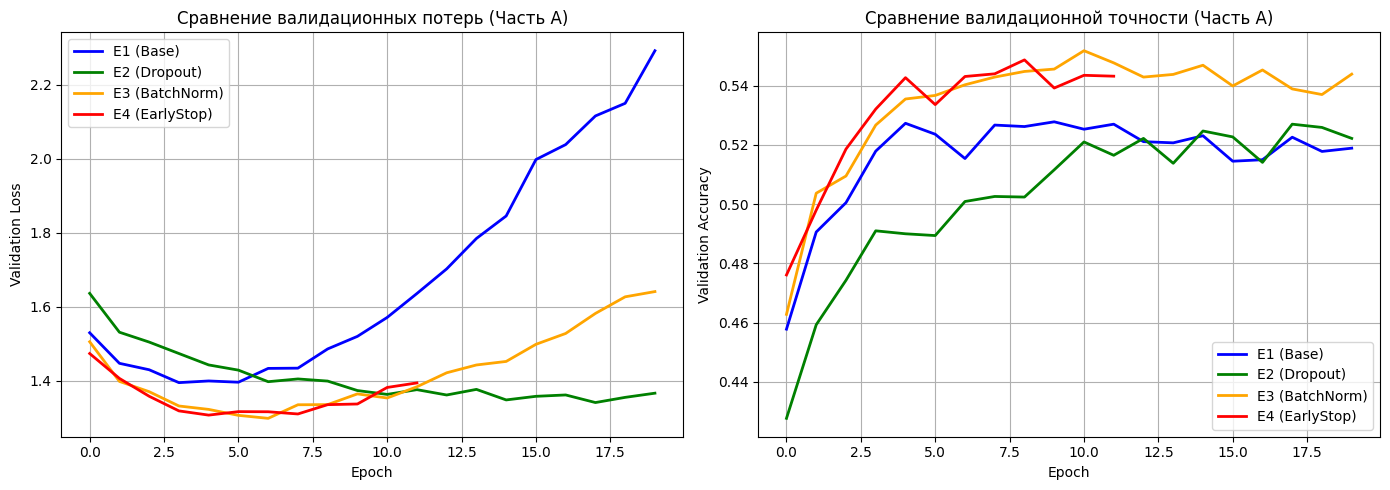

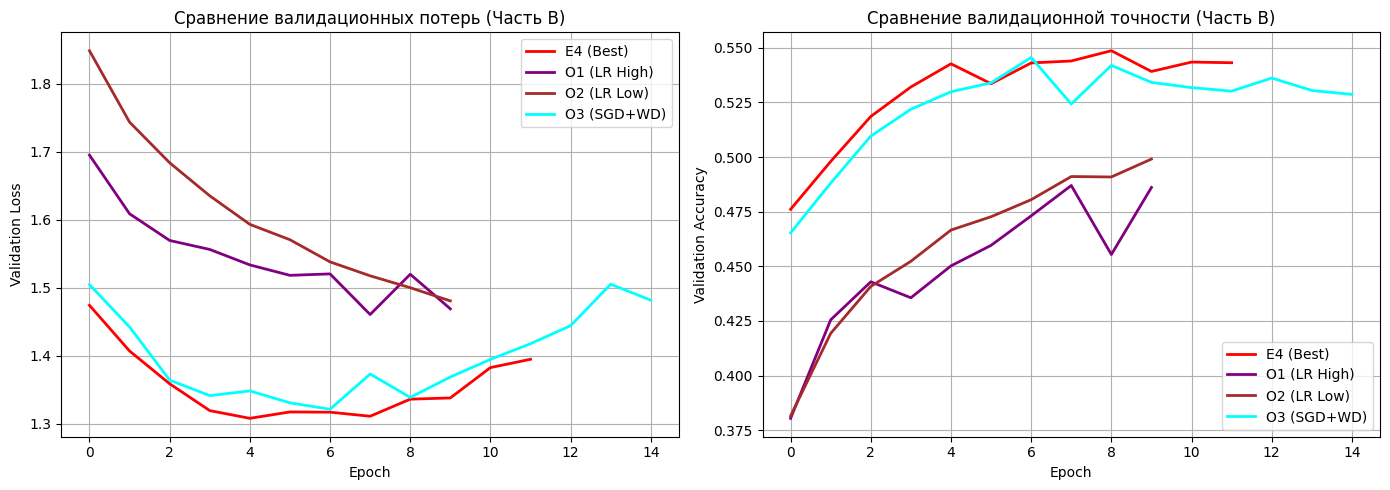

In [17]:
# --- Часть A: сравнение E1–E4 по val-метрикам ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_list_a  = [exp_e1, exp_e2, exp_e3, exp_e4]
names_a     = ['E1 (Base)', 'E2 (Dropout)', 'E3 (BatchNorm)', 'E4 (EarlyStop)']
colors_a    = ['blue', 'green', 'orange', 'red']

for exp, name, color in zip(exp_list_a, names_a, colors_a):
    axes[0].plot(exp.val_losses, label=name, color=color, linewidth=2)
    axes[1].plot(exp.val_accs,   label=name, color=color, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('Часть A — Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Часть A — Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/compare_part_a.png', dpi=150)
plt.show()

# --- Часть B: сравнение E4 (лучший) и O1–O3 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_list_b  = [exp_e4, exp_o1, exp_o2, exp_o3]
names_b     = ['E4 (Best)', 'O1 (LR High)', 'O2 (LR Low)', 'O3 (SGD+WD)']
colors_b    = ['red', 'purple', 'brown', 'cyan']

for exp, name, color in zip(exp_list_b, names_b, colors_b):
    axes[0].plot(exp.val_losses, label=name, color=color, linewidth=2)
    axes[1].plot(exp.val_accs,   label=name, color=color, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('Часть B — Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Часть B — Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/compare_part_b.png', dpi=150)
plt.show()


### 10. КРАТКИЕ ВЫВОДЫ ДЛЯ ОТЧЁТА (report.md)

In [18]:
print("\n" + "="*60)
print("ВЫВОДЫ ДЛЯ ОТЧЁТА")
print("="*60)

part_a_mask = df_results['experiment_id'].isin(['E1', 'E2', 'E3', 'E4'])
best_exp_a = df_results[part_a_mask].loc[
    df_results[part_a_mask]['best_val_accuracy'].idxmax()
]

print(f"""
1. Что сделано
   - Датасет: {DATASET_NAME}
   - Часть A: исследовались Dropout, BatchNorm, EarlyStopping
   - Часть B: анализировались крайние значения LR, Adam vs SGD+momentum+weight_decay

2. Лучшие результаты (Часть A):
   - Лучший эксперимент: {best_exp_a['experiment_id']}
   - val_accuracy:  {best_exp_a['best_val_accuracy']:.4f}
   - test_accuracy: {test_acc:.4f}

3. O1 (LR завышен): нестабильный loss, точность не сходится
4. O2 (LR занижен): крайне медленная сходимость, недостаточно эпох
5. O3 (SGD+momentum+WD): результат сопоставим с Adam, требует тщательного подбора LR
""")

print("Артефакты:")
print("  artifacts/runs.csv           — таблица всех прогонов")
print("  artifacts/best_model.pt      — веса лучшей модели")
print("  artifacts/best_config.json   — конфигурация лучшей модели")
print("  artifacts/figures/curves_best.png        — кривые лучшего прогона")
print("  artifacts/figures/curves_lr_extremes.png — кривые крайних LR")



ВЫВОДЫ ДЛЯ ЗАПОЛНЕНИЯ ОТЧЕТА

1. Кратко: что сделано
   - Датасет: CIFAR10
   - Сравнивалось в части A: Dropout, BatchNorm, EarlyStopping
   - Сравнивалось в части B: Learning Rate (слишком большой/маленький), Adam vs SGD+momentum+weight_decay

2. Лучшие результаты части A:
   - Лучший эксперимент: E3
   - Лучшая val_accuracy: 0.5518
   - Итоговая test_accuracy: 0.5387

3. Что видно на O1 (слишком большой LR):
   - Loss нестабильный, возможны всплески
   - Точность не сходится или колеблется

4. Что видно на O2 (слишком маленький LR):
   - Loss уменьшается очень медленно
   - Точность растет медленно, не успевает сойтись за 10 эпох

5. Как повёл себя O3 (SGD+momentum + weight decay):
   - SGD с momentum обычно требует более тщательного подбора LR
   - Weight decay помогает от переобучения
   - Сравнить с Adam по кривым в artifacts/figures/curves_lr_extremes.png


Файлы артефактов:
- artifacts/runs.csv - таблица результатов
- artifacts/best_model.pt - лучшая модель
- artifacts/best_con